In [1]:
"""
MR-GNODE Analysis Notebook
Cell 1: Setup and Imports
"""

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import CCA
from sklearn.linear_model import Ridge
import seaborn as sns
import json
import os
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Configure matplotlib for publication-quality SVG output
matplotlib.rcParams['svg.fonttype'] = 'none'  # Save fonts as text in SVG
matplotlib.rcParams['font.size'] = 12
matplotlib.rcParams['axes.linewidth'] = 1.2
matplotlib.rcParams['xtick.major.width'] = 1.2
matplotlib.rcParams['ytick.major.width'] = 1.2
matplotlib.rcParams['figure.dpi'] = 300
matplotlib.rcParams['savefig.dpi'] = 300
matplotlib.rcParams['savefig.format'] = 'svg'
matplotlib.rcParams['savefig.bbox'] = 'tight'
matplotlib.rcParams['axes.spines.top'] = False
matplotlib.rcParams['axes.spines.right'] = False

# Set style
# plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

def load_config(config_path):
    """Load configuration from JSON file"""
    with open(config_path, 'r') as f:
        return json.load(f)

def compute_mse(preds, targets):
    """Compute Mean Squared Error"""
    return float(np.mean((preds - targets) ** 2))

def compute_r2(preds, targets):
    """Compute R-squared"""
    ss_res = np.sum((targets - preds) ** 2)
    ss_tot = np.sum((targets - np.mean(targets)) ** 2)
    return float(1 - (ss_res / ss_tot)) if ss_tot != 0 else 0.0

def count_parameters(model):
    """Count trainable parameters in a model"""
    if hasattr(model, 'parameters'):
        return sum(p.numel() for p in model.parameters() if p.requires_grad)
    return 0

def save_figure(fig, filename, dpi=300):
    """Save figure as high-quality SVG"""
    fig.savefig(f"{filename}.svg", format='svg', dpi=dpi, bbox_inches='tight', 
                facecolor='white', edgecolor='none')
    print(f"Saved: {filename}.svg")

print("✓ Imports and setup complete")

Using device: cuda
✓ Imports and setup complete


In [2]:
import os
os.chdir('src')


In [3]:
"""
Simplified Model Loading - Motor RNN + Best CV Models
"""

import os
import torch
import pickle
import json

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Import MRM infrastructure
from utils import load_config, create_model
from comparison import generate_common_test_data

print("Loading models from Motor RNN + Best CV folds...")

def load_best_cv_model(base_cache_path, config, model_name):
    """Load the best performing model from CV folds"""
    cv_cache_path = base_cache_path + '_cv'
    cv_results_path = os.path.join(cv_cache_path, 'cv_results.json')
    
    if not os.path.exists(cv_results_path):
        print(f"  {model_name} CV results not found")
        return None, None
    
    # Load CV results and find best fold
    with open(cv_results_path, 'r') as f:
        cv_results = json.load(f)
    
    best_r2 = -1
    best_fold = 0
    for fold_result in cv_results['fold_results']:
        if fold_result['test_r2'] > best_r2:
            best_r2 = fold_result['test_r2']
            best_fold = fold_result['fold_idx']
    
    # Load from best fold
    fold_path = os.path.join(cv_cache_path, f'cv_fold_{best_fold}')
    
    # Try torch format first
    torch_path = os.path.join(fold_path, 'model.pt')
    if os.path.exists(torch_path):
        state_dict = torch.load(torch_path, map_location=device)
        # Remove _orig_mod. prefix if present
        if any(k.startswith('_orig_mod.') for k in state_dict.keys()):
            state_dict = {k.replace('_orig_mod.', ''): v for k, v in state_dict.items()}
        
        # Create model and load state dict
        model = create_model(config)
        model.load_state_dict(state_dict)
        model.to(device)
        
        # Get metadata
        meta_path = os.path.join(fold_path, 'metadata.json')
        metadata = {'test_r2': best_r2, 'fold_idx': best_fold}
        if os.path.exists(meta_path):
            with open(meta_path, 'r') as f:
                fold_metadata = json.load(f)
            metadata.update(fold_metadata)
        
        print(f"✓ {model_name} loaded from CV fold {best_fold} (R²={best_r2:.3f})")
        return model, metadata
    
    # Try pickle format
    pickle_path = os.path.join(fold_path, 'model.pkl')
    if os.path.exists(pickle_path):
        with open(pickle_path, 'rb') as f:
            model = pickle.load(f)
        
        metadata = {'test_r2': best_r2, 'fold_idx': best_fold}
        print(f"✓ {model_name} loaded from CV fold {best_fold} (R²={best_r2:.3f})")
        return model, metadata
    
    print(f"  {model_name} model file not found in CV fold {best_fold}")
    return None, None

# =================================
# 1. Load Motor RNN (Ground Truth)
# =================================
print("\n1. Loading Motor RNN (Ground Truth)...")
motor_rnn_config = load_config('configs/motor_rnn.json')

# Regular loading for Motor RNN
model_path = os.path.join(motor_rnn_config['cache_path'], "model.pt")
meta_path = os.path.join(motor_rnn_config['cache_path'], "metadata.json")

if os.path.exists(model_path):
    motor_rnn_model = create_model(motor_rnn_config)
    state_dict = torch.load(model_path, map_location=device)
    if any(k.startswith('_orig_mod.') for k in state_dict.keys()):
        state_dict = {k.replace('_orig_mod.', ''): v for k, v in state_dict.items()}
    motor_rnn_model.load_state_dict(state_dict)
    motor_rnn_model.to(device)
    
    motor_rnn_metadata = {}
    if os.path.exists(meta_path):
        with open(meta_path, 'r') as f:
            motor_rnn_metadata = json.load(f)
    
    print(f"✓ Motor RNN loaded from {motor_rnn_config['cache_path']}")
    if 'final_r2' in motor_rnn_metadata:
        print(f"  Performance: R² = {motor_rnn_metadata['final_r2']:.3f}")
else:
    raise ValueError("Motor RNN not found! Train with: python train.py configs/motor_rnn.json")

# =================================
# 2. Load CV Models
# =================================
print("\n2. Loading CV Models...")

# MR-GNODE
mr_gnode_config = load_config('configs/mr_gnode.json')
mr_gnode_model, mr_gnode_metadata = load_best_cv_model(
    mr_gnode_config['cache_path'], mr_gnode_config, "MR-GNODE"
)

# MP-rSLDS  
mp_rslds_config = load_config('configs/mp_rslds.json')
mp_rslds_model, mp_rslds_metadata = load_best_cv_model(
    mp_rslds_config['cache_path'], mp_rslds_config, "MP-rSLDS"
)

# RRR
rrr_config = load_config('configs/rrr.json')
rrr_model, rrr_metadata = load_best_cv_model(
    rrr_config['cache_path'], rrr_config, "RRR"
)

# =================================
# 3. Load Cross-Validation Results
# =================================
print("\n3. Loading Cross-Validation Results...")

def load_cv_results(config):
    """Load CV results if available"""
    if config is None:
        return None
    cv_results_path = config['cache_path'] + '_cv/cv_results.json'
    if os.path.exists(cv_results_path):
        with open(cv_results_path, 'r') as f:
            return json.load(f)
    return None

cv_results = {
    'motor_rnn': None,  # Motor RNN doesn't have CV results
    'mr_gnode': load_cv_results(mr_gnode_config),
    'mp_rslds': load_cv_results(mp_rslds_config), 
    'rrr': load_cv_results(rrr_config)
}

for name, cv_data in cv_results.items():
    if cv_data:
        print(f"✓ {name} CV: MSE={cv_data['mean_test_mse']:.4f}±{cv_data['std_test_mse']:.4f}, "
              f"R²={cv_data['mean_test_r2']:.3f}±{cv_data['std_test_r2']:.3f} ({cv_data['n_folds']} folds)")
    else:
        print(f"  {name} CV: Not available")

# =================================
# 4. Generate Common Test Data
# =================================
print("\n4. Generating common test trajectories...")
test_data = generate_common_test_data()

print(f"✓ Generated {len(test_data['trial_info'])} test trials")
print(f"  Evidence states shape: {test_data['evidence_states'].shape}")
print(f"  Motor states shape: {test_data['motor_states'].shape}")

# =================================
# Summary
# =================================
print("\n" + "="*50)
print("MODEL LOADING SUMMARY")
print("="*50)

models = {
    'motor_rnn': motor_rnn_model,
    'mr_gnode': mr_gnode_model, 
    'mp_rslds': mp_rslds_model,
    'rrr': rrr_model
}

configs = {
    'motor_rnn': motor_rnn_config,
    'mr_gnode': mr_gnode_config,
    'mp_rslds': mp_rslds_config,
    'rrr': rrr_config
}

metadata = {
    'motor_rnn': motor_rnn_metadata,
    'mr_gnode': mr_gnode_metadata,
    'mp_rslds': mp_rslds_metadata,
    'rrr': rrr_metadata
}

for name, model in models.items():
    status = "✓ Loaded" if model is not None else "✗ Missing"
    cv_status = "✓ CV" if cv_results[name] else "✗ CV" 
    print(f"{status:10} {cv_status:6} {name}")

print(f"✓ Test Data: {len(test_data['trial_info'])} trials")
print("="*50)

Loading models from Motor RNN + Best CV folds...

1. Loading Motor RNN (Ground Truth)...
✓ Motor RNN loaded from cache/decision_motor_rnn

2. Loading CV Models...
✓ MR-GNODE loaded from CV fold 2 (R²=0.987)
✓ MP-rSLDS loaded from CV fold 4 (R²=0.993)
✓ RRR loaded from CV fold 2 (R²=0.818)

3. Loading Cross-Validation Results...
  motor_rnn CV: Not available
✓ mr_gnode CV: MSE=0.0004±0.0000, R²=0.986±0.001 (5 folds)
✓ mp_rslds CV: MSE=0.0003±0.0000, R²=0.992±0.001 (5 folds)
✓ rrr CV: MSE=0.0072±0.0003, R²=0.806±0.009 (5 folds)

4. Generating common test trajectories...
Generating common test trajectories from RNN...
✓ Generated 20 test trials
  Evidence states shape: (20, 30, 64)
  Motor states shape: (20, 30, 64)

MODEL LOADING SUMMARY
✓ Loaded   ✗ CV   motor_rnn
✓ Loaded   ✓ CV   mr_gnode
✓ Loaded   ✓ CV   mp_rslds
✓ Loaded   ✓ CV   rrr
✓ Test Data: 20 trials


PANEL 1: Motor RNN 3D Dynamics
Using utils.extract_trajectories for high-quality dynamics...
Plotting dynamics for 80 trials...
Decision type distribution: LEFT=31, RIGHT=49
Fitting PCA models...
Evidence PCA explained variance: [0.92021483 0.05220671 0.00958148]
Motor PCA explained variance: [0.4107451  0.33465064 0.13861984]


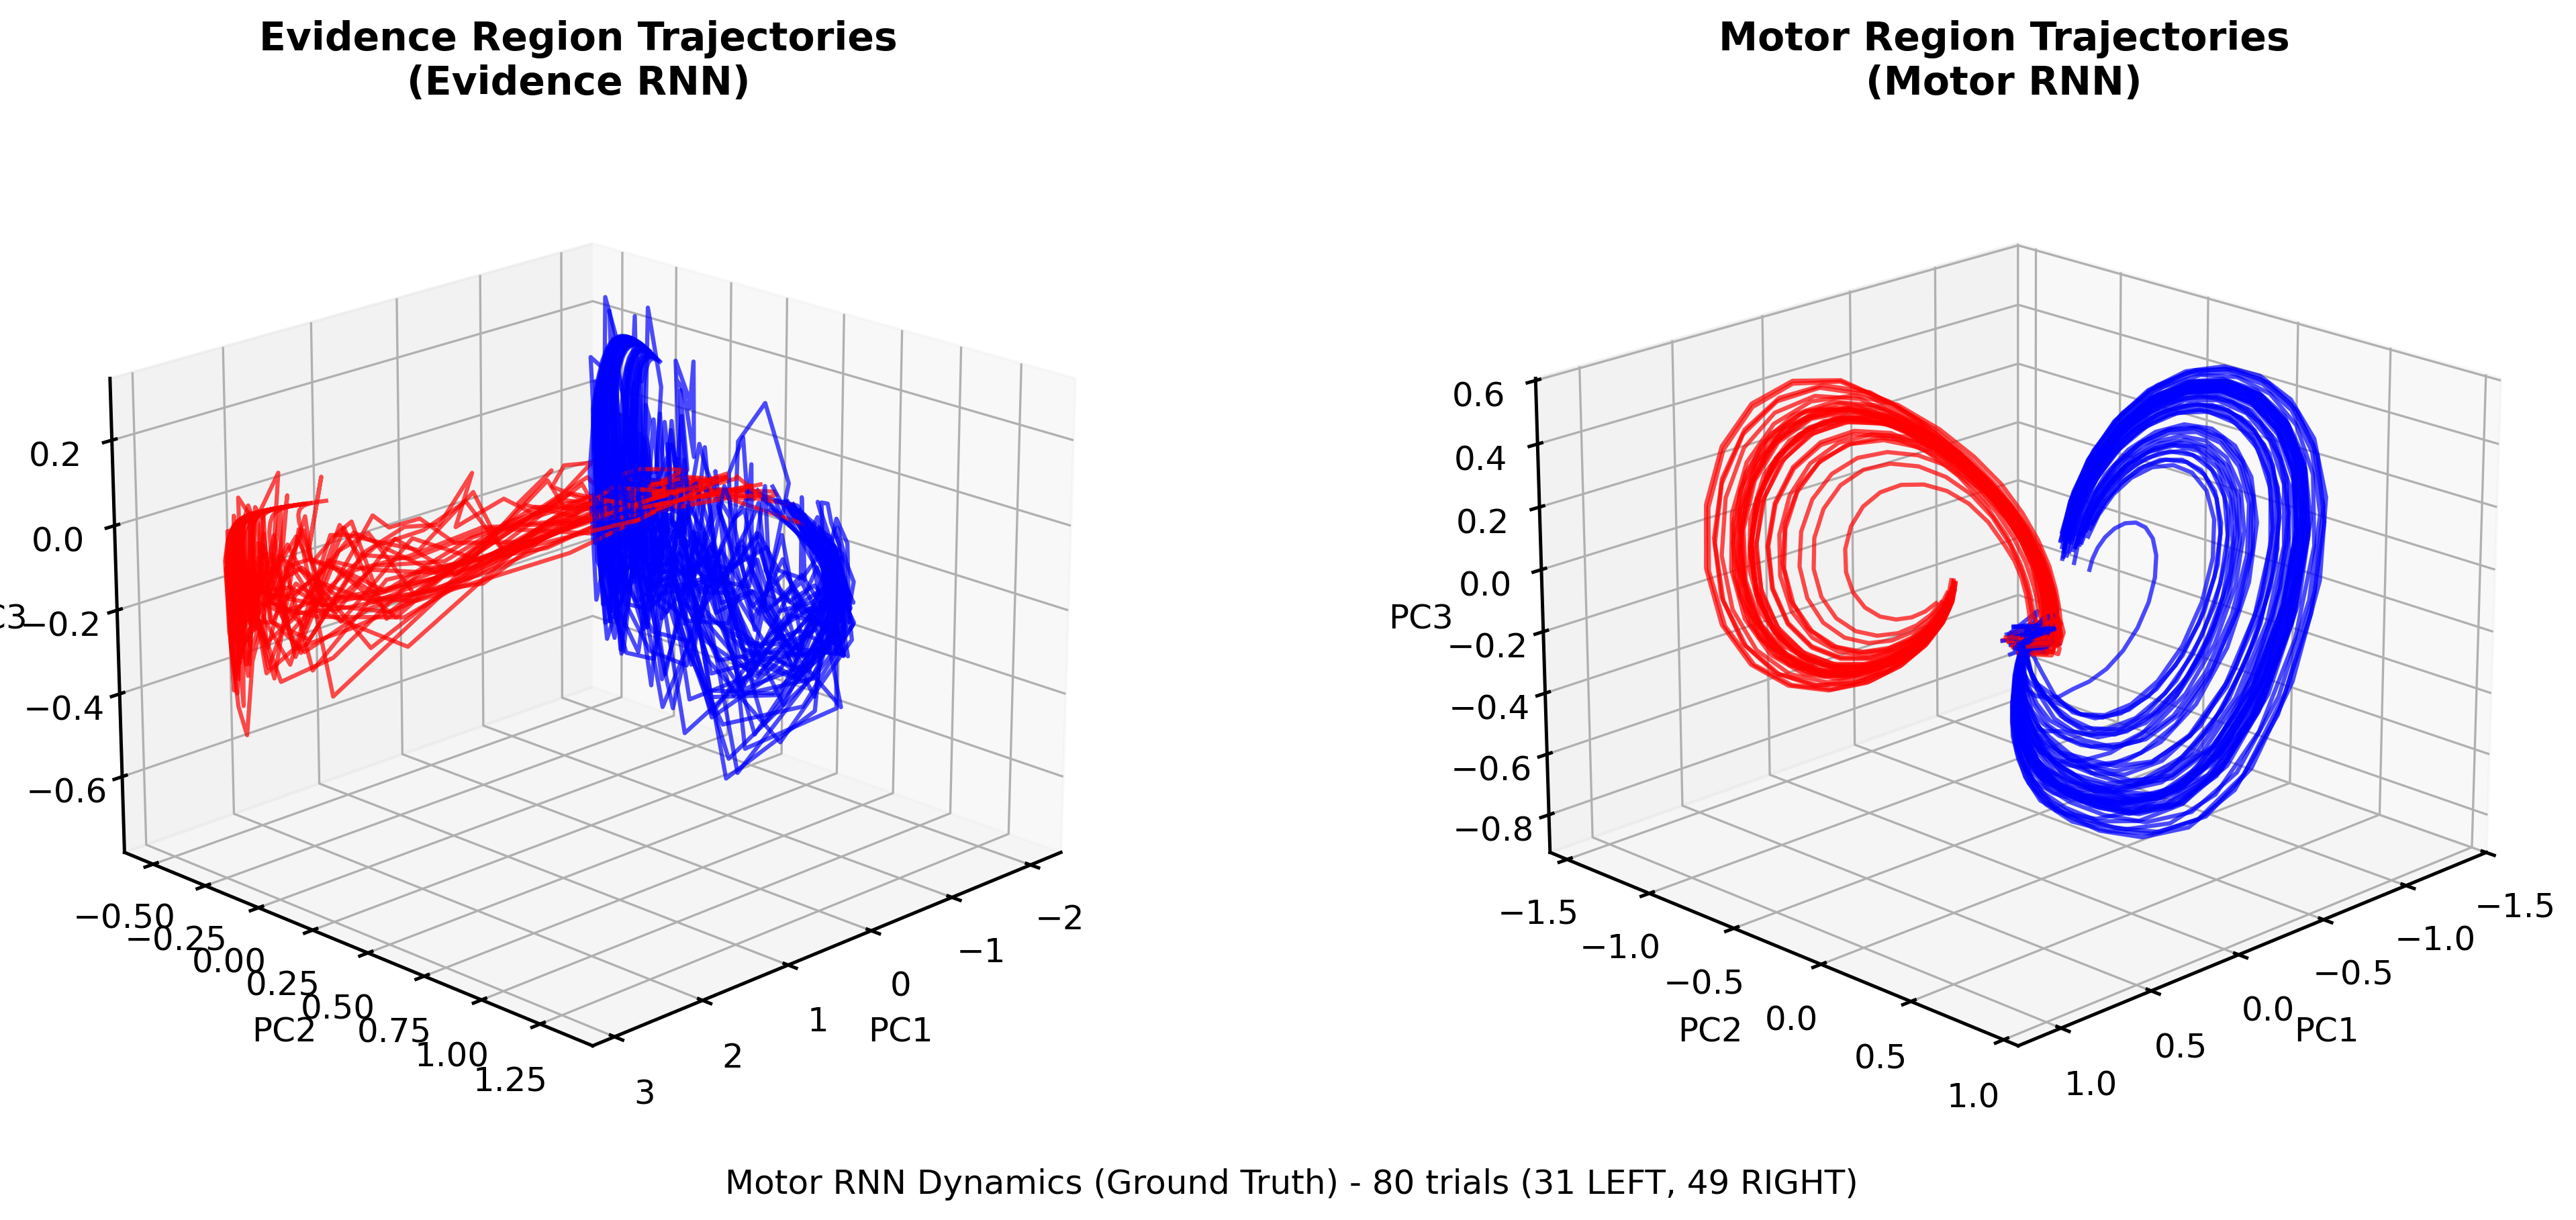

✓ Panel 1 complete


In [4]:
"""
Cell 3: Panel 1 - Motor RNN 3D Dynamics Visualization
"""

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
import torch

def plot_motor_rnn_3d_dynamics(trajectories_data):
    """Create 3D visualization using utils.extract_trajectories data"""
    
    print(f"Plotting dynamics for {len(trajectories_data['trial_info'])} trials...")
    
    # Get all data - utils format
    evidence_states = trajectories_data['evidence_states']
    motor_states = trajectories_data['motor_states']
    decision_types = [info['target'] for info in trajectories_data['trial_info']]
    
    print(f"Decision type distribution: LEFT={decision_types.count(0)}, RIGHT={decision_types.count(1)}")
    
    # Fit PCA models on all data
    print("Fitting PCA models...")
    evidence_flat = evidence_states.reshape(-1, evidence_states.shape[-1])
    motor_flat = motor_states.reshape(-1, motor_states.shape[-1])
    
    evidence_pca = PCA(n_components=3)
    motor_pca = PCA(n_components=3)
    
    evidence_pca_transformed = evidence_pca.fit_transform(evidence_flat)
    motor_pca_transformed = motor_pca.fit_transform(motor_flat)
    
    print(f"Evidence PCA explained variance: {evidence_pca.explained_variance_ratio_[:3]}")
    print(f"Motor PCA explained variance: {motor_pca.explained_variance_ratio_[:3]}")
    
    # Extract trajectories
    time_steps = evidence_states.shape[1]
    evidence_trajs = []
    motor_trajs = []
    
    for trial_idx in range(len(decision_types)):
        start_idx = trial_idx * time_steps
        end_idx = (trial_idx + 1) * time_steps
        
        evidence_trajs.append(evidence_pca_transformed[start_idx:end_idx])
        motor_trajs.append(motor_pca_transformed[start_idx:end_idx])
    
    # Create figure with all trajectories
    fig = plt.figure(figsize=(15, 6))
    colors = {0: 'red', 1: 'blue'}
    
    # Evidence Region 3D - plot ALL trajectories
    ax1 = fig.add_subplot(1, 2, 1, projection='3d')
    for trial_idx in range(len(decision_types)):
        decision_type = decision_types[trial_idx]
        traj = evidence_trajs[trial_idx]
        color = colors[decision_type]
        
        ax1.plot(traj[:, 0], traj[:, 1], traj[:, 2], 
                color=color, alpha=0.7, linewidth=1.5)
    
    ax1.set_title('Evidence Region Trajectories\n(Evidence RNN)', fontsize=14, fontweight='bold')
    ax1.set_xlabel('PC1')
    ax1.set_ylabel('PC2')
    ax1.set_zlabel('PC3')
    ax1.view_init(elev=20, azim=45)
    
    # Motor Region 3D - plot ALL trajectories
    ax2 = fig.add_subplot(1, 2, 2, projection='3d')
    for trial_idx in range(len(decision_types)):
        decision_type = decision_types[trial_idx]
        traj = motor_trajs[trial_idx]
        color = colors[decision_type]
        
        ax2.plot(traj[:, 0], traj[:, 1], traj[:, 2], 
                color=color, alpha=0.7, linewidth=1.5)
    
    ax2.set_title('Motor Region Trajectories\n(Motor RNN)', fontsize=14, fontweight='bold')
    ax2.set_xlabel('PC1')
    ax2.set_ylabel('PC2')
    ax2.set_zlabel('PC3')
    ax2.view_init(elev=20, azim=45)
    
    plt.tight_layout()
    
    # Summary
    total_trials = len(decision_types)
    left_count = decision_types.count(0)
    right_count = decision_types.count(1)
    summary_text = f"Motor RNN Dynamics (Ground Truth) - {total_trials} trials ({left_count} LEFT, {right_count} RIGHT)"
    fig.suptitle(summary_text, fontsize=12, y=0.02)
    
    plt.show()
    
    return {
        'evidence_pca': evidence_pca,
        'motor_pca': motor_pca,
        'trajectories': {'evidence': evidence_trajs, 'motor': motor_trajs},
        'decision_types': decision_types
    }, fig

# Execute Panel 1
print("="*50)
print("PANEL 1: Motor RNN 3D Dynamics")
print("="*50)

# Use the utils.extract_trajectories method that gives 88% variance explained
print("Using utils.extract_trajectories for high-quality dynamics...")
from utils import extract_trajectories

# Extract using the proven method
high_quality_trajectories = extract_trajectories(models['motor_rnn'], n_trials=80)

motor_rnn_dynamics, panel1_fig = plot_motor_rnn_3d_dynamics(high_quality_trajectories)
print("✓ Panel 1 complete")

PANEL 2: Cross-Validated Model Performance
Cross-Validation Results Summary:
------------------------------------------------------------
MOTOR_RNN    | No CV results available
MR_GNODE     | MSE: 0.0004±0.0000 | R²: 0.986±0.001 | Folds: 5
MP_RSLDS     | MSE: 0.0003±0.0000 | R²: 0.992±0.001 | Folds: 5
RRR          | MSE: 0.0072±0.0003 | R²: 0.806±0.009 | Folds: 5
------------------------------------------------------------


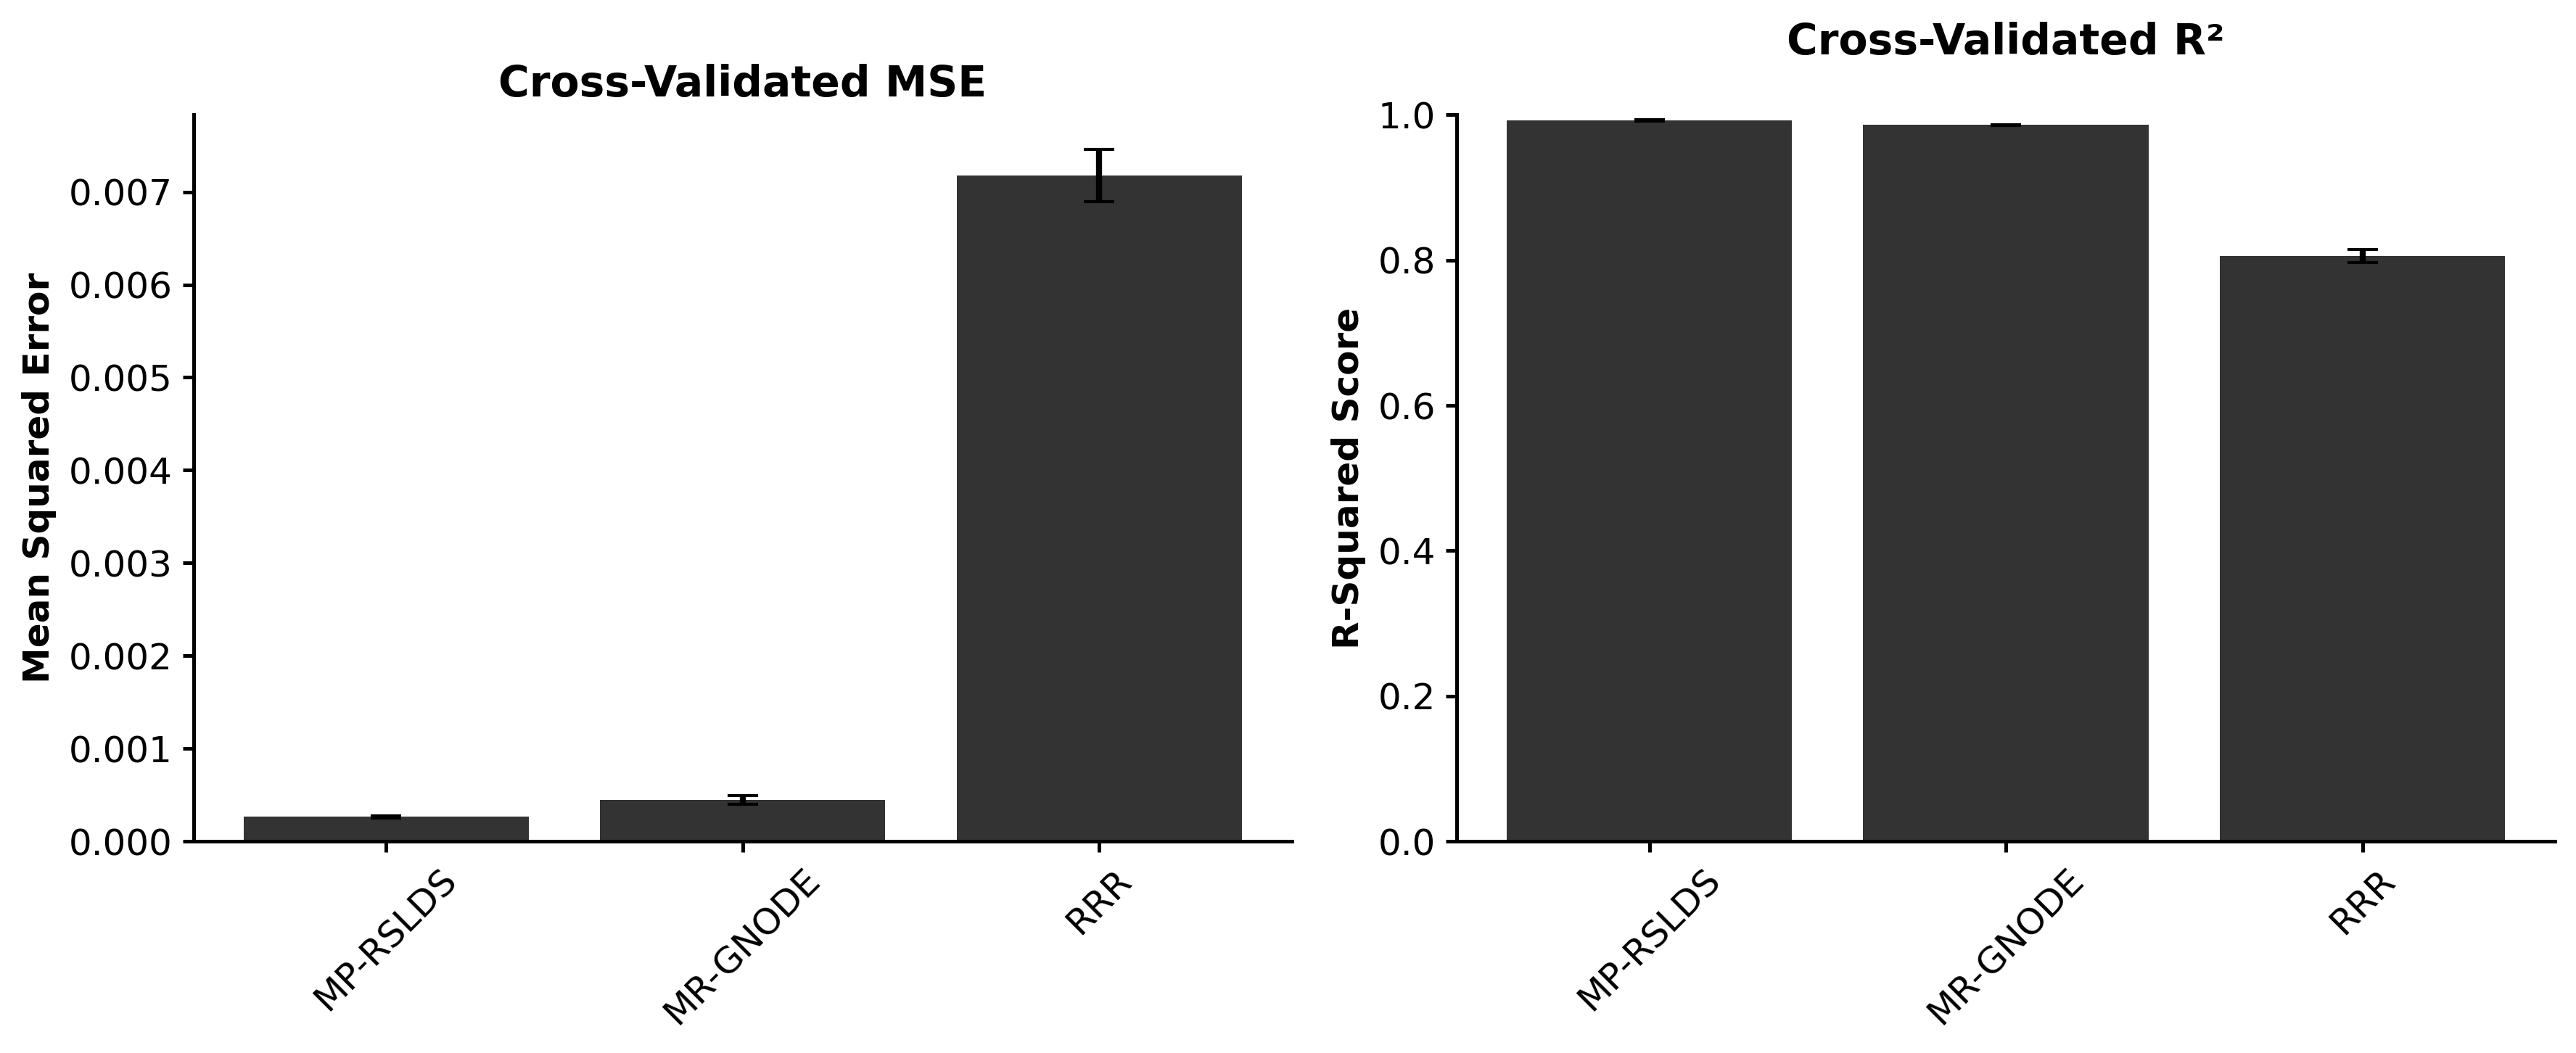

In [10]:
"""
Cell 4: Panel 2 - Cross-Validated Model Performance Comparison
"""

def plot_cv_comparison(cv_results):
    """Create clean black bar plots with error bars from CV results"""
    
    # Extract models with CV results
    model_data = []
    for name, cv_data in cv_results.items():
        if cv_data is not None:
            model_data.append({
                'name': name.replace('_', '-').upper(),
                'mse_mean': cv_data['mean_test_mse'],
                'mse_std': cv_data['std_test_mse'],
                'r2_mean': cv_data['mean_test_r2'], 
                'r2_std': cv_data['std_test_r2']
            })
    
    if not model_data:
        print("⚠ No cross-validation results available")
        return None
    
    # Sort by R² performance (descending)
    model_data.sort(key=lambda x: x['r2_mean'], reverse=True)
    
    model_names = [d['name'] for d in model_data]
    mse_means = [d['mse_mean'] for d in model_data]
    mse_stds = [d['mse_std'] for d in model_data]
    r2_means = [d['r2_mean'] for d in model_data]
    r2_stds = [d['r2_std'] for d in model_data]
    
    # Create figure
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # MSE plot
    bars1 = ax1.bar(model_names, mse_means, yerr=mse_stds, 
                    color='black', alpha=0.8, capsize=5, 
                    error_kw={'linewidth': 2})
    ax1.set_ylabel('Mean Squared Error', fontweight='bold', fontsize=12)
    ax1.set_title('Cross-Validated MSE', fontsize=14, fontweight='bold')
    ax1.tick_params(axis='x', rotation=45)
    
    # # Add value labels
    # for bar, mean, std in zip(bars1, mse_means, mse_stds):
    #     height = bar.get_height()
    #     ax1.text(bar.get_x() + bar.get_width()/2., height + std + height*0.05,
    #             f'{mean:.4f}±{std:.4f}', ha='center', va='bottom', 
    #             fontweight='bold', fontsize=10)
    
    # R² plot
    bars2 = ax2.bar(model_names, r2_means, yerr=r2_stds,
                    color='black', alpha=0.8, capsize=5,
                    error_kw={'linewidth': 2})
    
    ax2.set_ylabel('R-Squared Score', fontweight='bold', fontsize=12)
    ax2.set_title('Cross-Validated R²', fontsize=14, fontweight='bold', pad=20)
    ax2.tick_params(axis='x', rotation=45)
    ax2.set_ylim(0, 1.0)
    
    # Add value labels
    # for bar, mean, std in zip(bars2, r2_means, r2_stds):
    #     height = bar.get_height()
    #     ax2.text(bar.get_x() + bar.get_width()/2., height + std + 0.02,
    #             f'{mean:.3f}±{std:.3f}', ha='center', va='bottom',
    #             fontweight='bold', fontsize=10)
    
    plt.tight_layout()
    
    return fig

# ================================
# Panel 2: CV Performance Comparison  
# ================================
print("="*50)
print("PANEL 2: Cross-Validated Model Performance")
print("="*50)

# Display CV summary table
print("Cross-Validation Results Summary:")
print("-" * 60)
for name, cv_data in cv_results.items():
    if cv_data is not None:
        print(f"{name.upper():12} | MSE: {cv_data['mean_test_mse']:.4f}±{cv_data['std_test_mse']:.4f} | "
              f"R²: {cv_data['mean_test_r2']:.3f}±{cv_data['std_test_r2']:.3f} | "
              f"Folds: {cv_data['n_folds']}")
    else:
        print(f"{name.upper():12} | No CV results available")

print("-" * 60)

# Create comparison plot
cv_fig = plot_cv_comparison(cv_results)



PANEL 3: MR-GNODE Example Trial + Trial Averages
Extracting MR-GNODE trajectories...
✓ Extracted 20 trials
MR-GNODE Reconstruction Quality:
  Evidence Region R²: 0.994
  Motor Region R²: 0.979
Creating MR-GNODE comparison plot...


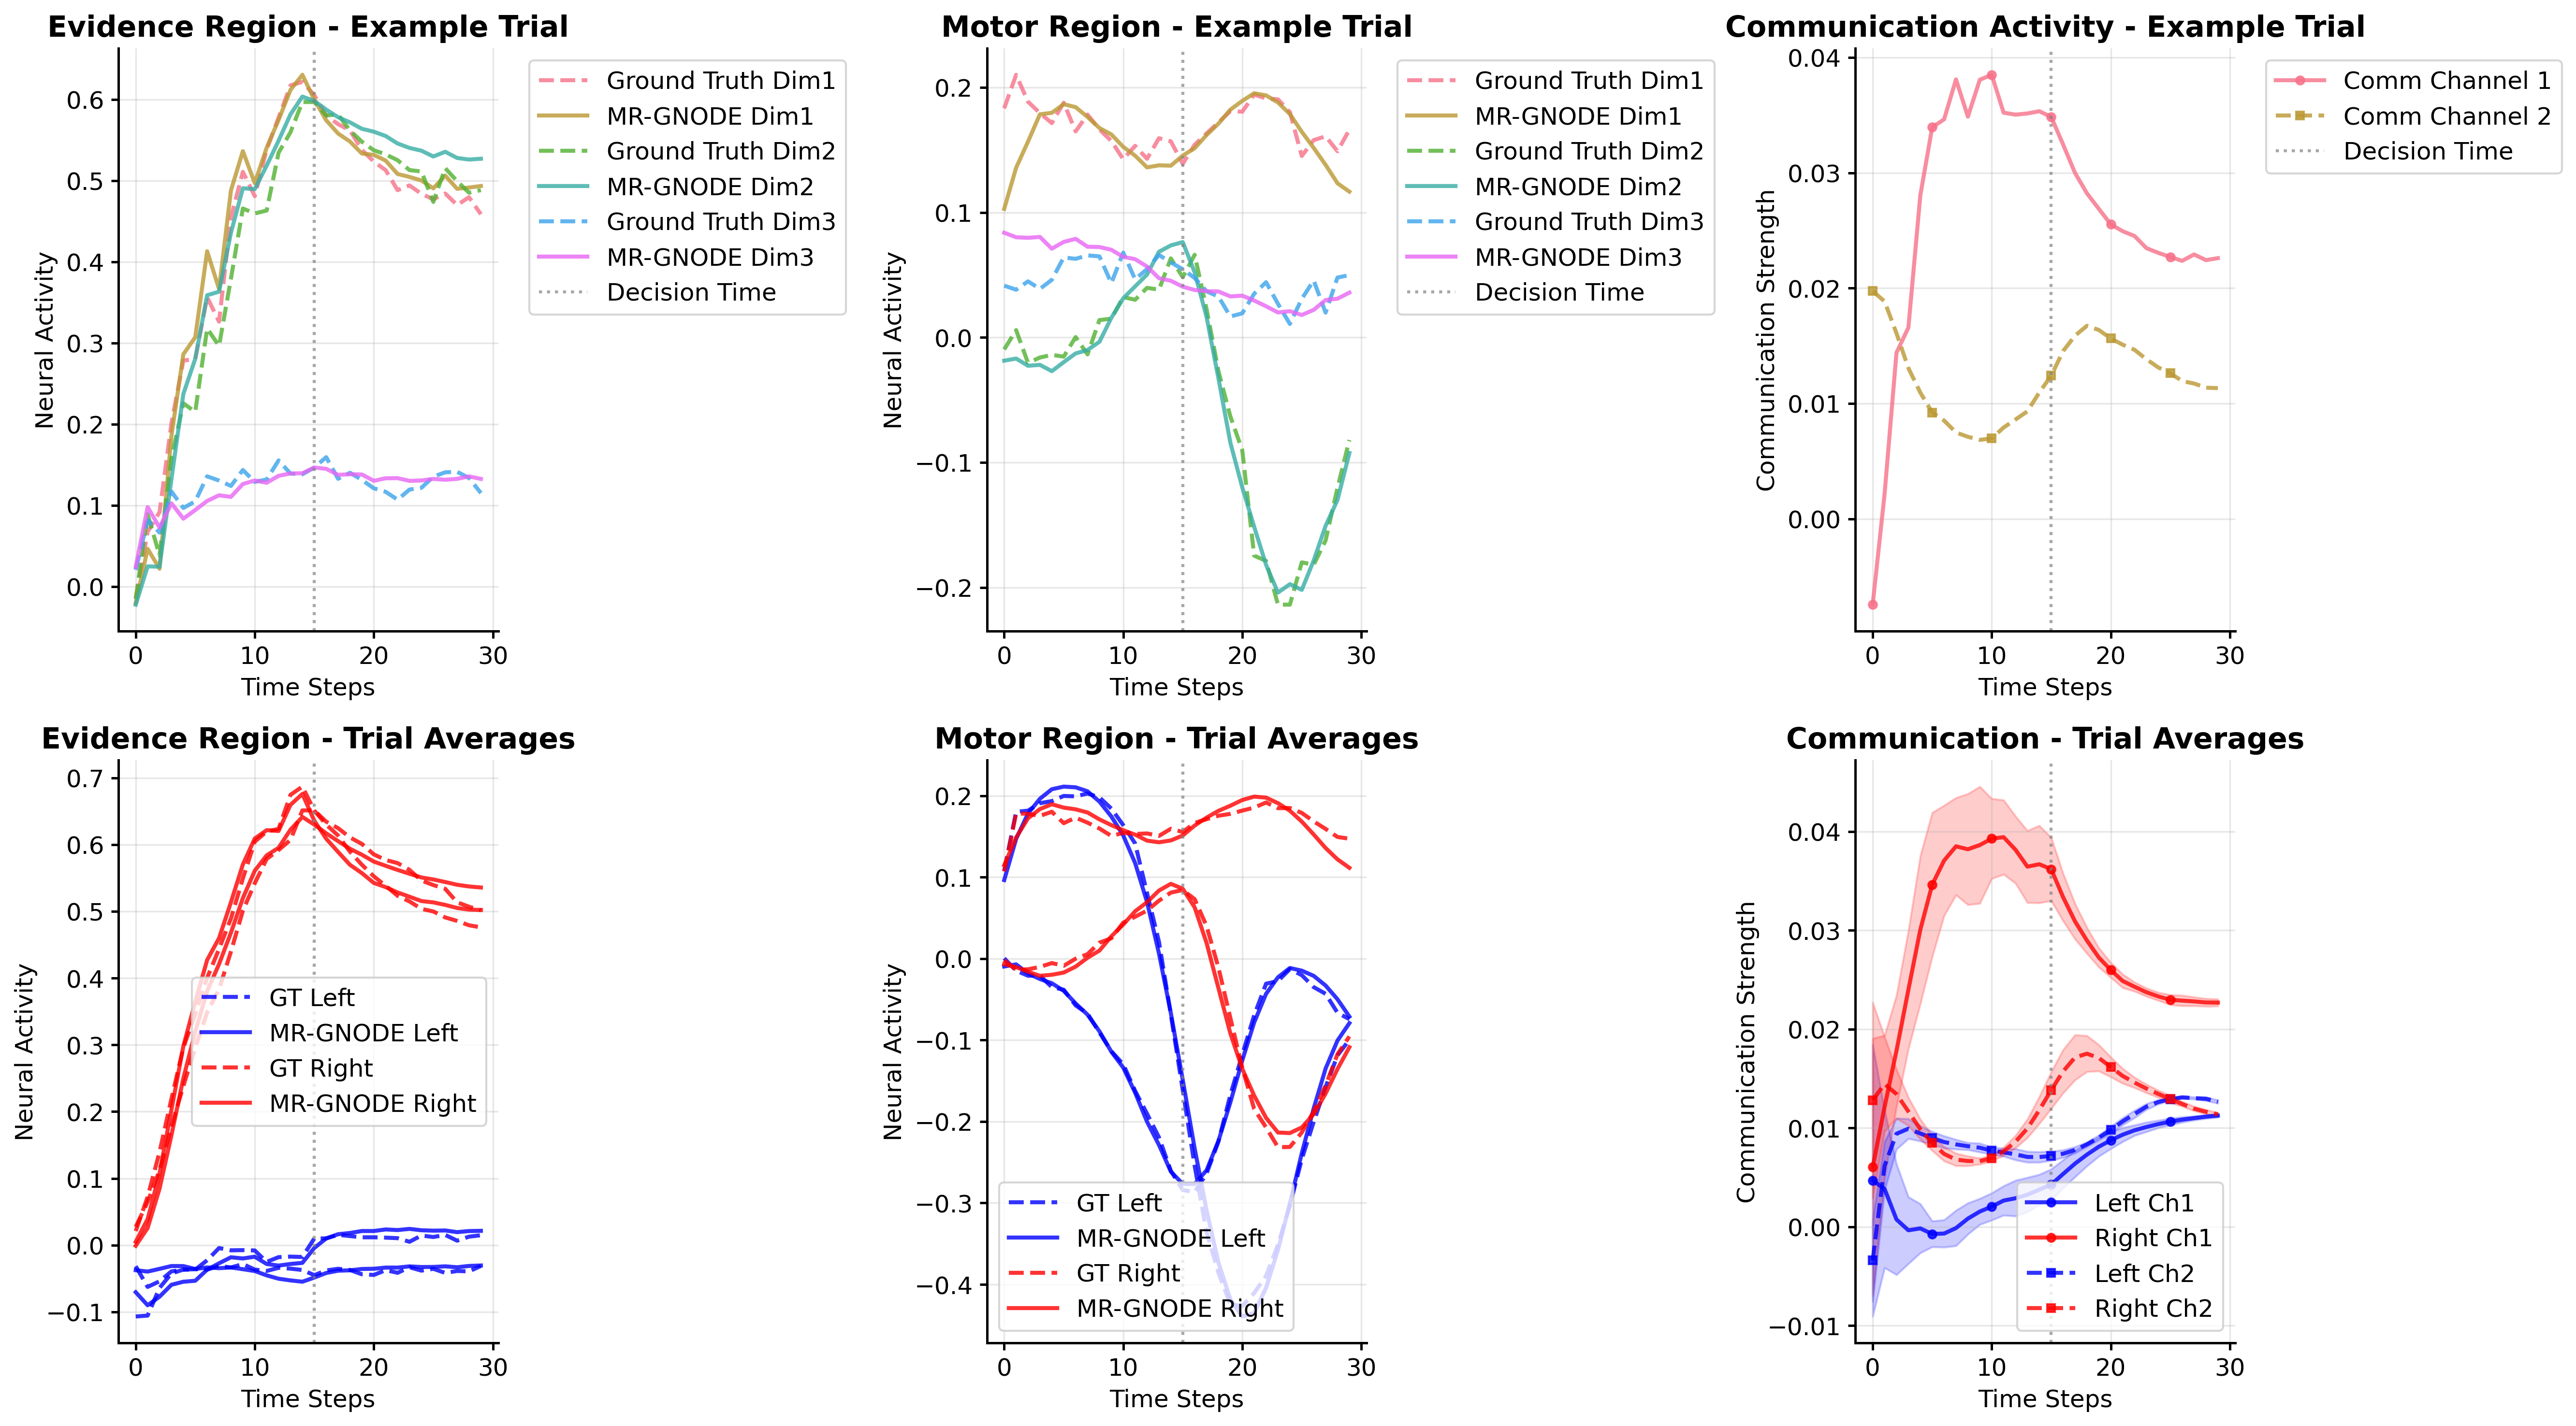


✓ Panel 3 complete - MR-GNODE detailed analysis


In [15]:
"""
Cell 5: Panel 3 - MR-GNODE Example Trial + Trial Averages
"""

def extract_mrgnod_trajectories(model, test_data, device, n_trials=20):
    """Extract trajectories from MR-GNODE model"""
    if model is None:
        return None
        
    evidence_states = test_data['evidence_states'][:n_trials]
    motor_states = test_data['motor_states'][:n_trials]
    trial_info = test_data['trial_info'][:n_trials]
    
    evidence_tensor = torch.tensor(evidence_states, dtype=torch.float32).to(device)
    motor_tensor = torch.tensor(motor_states, dtype=torch.float32).to(device)
    n_trials, seq_len, _ = evidence_tensor.shape
    dt = 0.01
    
    model.eval()
    all_evidence_states = []
    all_motor_states = []
    all_communications = []
    
    with torch.no_grad():
        for trial_idx in range(n_trials):
            trial_evidence = evidence_tensor[trial_idx:trial_idx+1]
            trial_motor = motor_tensor[trial_idx:trial_idx+1]
            
            # Initialize hidden state
            h = torch.empty(1, model.N_total, device=device)
            torch.nn.init.xavier_uniform_(h)
            
            trial_evidence_states = []
            trial_motor_states = []
            trial_communications = []
            
            for t in range(seq_len):
                # Format input: evidence + motor concatenated then split to regions
                evidence_t = trial_evidence[:, t, :]  # [1, 64]
                motor_t = trial_motor[:, t, :]        # [1, 64]
                
                # Concatenate and reshape to [batch, num_regions, region_dim]
                combined = torch.cat([evidence_t, motor_t], dim=-1)  # [1, 128]
                u_t = combined.view(1, 2, 64)  # [1, 2, 64] - region 1=evidence, region 2=motor
                
                # Forward step
                h_dot, comm_activity = model(h, u_t, timestep=t)
                h = h + dt * h_dot
                
                # Extract region outputs
                region_outputs = model.get_outputs(h)  # [1, 2, 64]
                
                # Store region outputs
                evidence_state = region_outputs[:, 0, :]  # Region 1 output
                motor_state = region_outputs[:, 1, :]     # Region 2 output
                
                trial_evidence_states.append(evidence_state.cpu())
                trial_motor_states.append(motor_state.cpu())
                
                # Store communication activity - extract actual channels, not just norm
                h_regions_step, h_comm_step = model.partition_state(h)
                
                # Average over comm_dim to get one value per channel
                comm_channels = h_comm_step.mean(dim=-1)  # [1, num_comm_channels]
                trial_communications.append(comm_channels.cpu())
            
            all_evidence_states.append(torch.stack(trial_evidence_states, dim=1))
            all_motor_states.append(torch.stack(trial_motor_states, dim=1))
            all_communications.append(torch.stack(trial_communications, dim=1))
    
    return {
        'evidence_states': torch.cat(all_evidence_states, dim=0).numpy(),
        'motor_states': torch.cat(all_motor_states, dim=0).numpy(),
        'communications': torch.cat(all_communications, dim=0).numpy(),
        'trial_info': trial_info
    }

def plot_mrgnod_comparison(mrgnod_trajectories, ground_truth_data, example_trial_idx=5):
    """Create comprehensive MR-GNODE vs Motor RNN comparison"""
    
    if mrgnod_trajectories is None:
        # Create placeholder plot if MR-GNODE not available
        fig, axes = plt.subplots(2, 3, figsize=(18, 10))
        for ax in axes.flat:
            ax.text(0.5, 0.5, 'MR-GNODE\nNot Available\n\nTrain with:\npython train.py\nconfigs/mr_gnode.json', 
                   ha='center', va='center', fontsize=12, 
                   bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray", alpha=0.5))
            ax.set_xlim(0, 1)
            ax.set_ylim(0, 1)
        
        axes[0,0].set_title('Evidence Region Comparison', fontweight='bold')
        axes[0,1].set_title('Motor Region Comparison', fontweight='bold') 
        axes[0,2].set_title('Communication Activity', fontweight='bold')
        axes[1,0].set_title('Evidence Averages by Decision', fontweight='bold')
        axes[1,1].set_title('Motor Averages by Decision', fontweight='bold')
        axes[1,2].set_title('Communication Averages', fontweight='bold')
        
        plt.tight_layout()
        return fig
    
    # Extract data
    mrgnod_evidence = mrgnod_trajectories['evidence_states']
    mrgnod_motor = mrgnod_trajectories['motor_states'] 
    mrgnod_comm = mrgnod_trajectories['communications']
    
    gt_evidence = ground_truth_data['evidence_states'][:len(mrgnod_evidence)]
    gt_motor = ground_truth_data['motor_states'][:len(mrgnod_evidence)]
    trial_info = ground_truth_data['trial_info'][:len(mrgnod_evidence)]
    
    # Get decision labels
    decisions = [info['target'] for info in trial_info]
    
    # Create figure
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    
    time_points = np.arange(mrgnod_evidence.shape[1])
    
    # ================================
    # Top Row: Example Trial
    # ================================
    
    # Evidence region comparison (top-left)
    ax = axes[0,0]
    
    # Plot first 3 dimensions for visualization
    for pc in range(min(3, mrgnod_evidence.shape[2])):
        ax.plot(time_points, gt_evidence[example_trial_idx, :, pc], 
               '--', linewidth=2, alpha=0.8, label=f'Ground Truth Dim{pc+1}')
        ax.plot(time_points, mrgnod_evidence[example_trial_idx, :, pc], 
               '-', linewidth=2, alpha=0.8, label=f'MR-GNODE Dim{pc+1}')
    
    ax.axvline(x=15, color='gray', linestyle=':', alpha=0.7, label='Decision Time')
    ax.set_title('Evidence Region - Example Trial', fontweight='bold')
    ax.set_xlabel('Time Steps')
    ax.set_ylabel('Neural Activity')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(True, alpha=0.3)
    
    # Motor region comparison (top-center)
    ax = axes[0,1]
    
    for pc in range(min(3, mrgnod_motor.shape[2])):
        ax.plot(time_points, gt_motor[example_trial_idx, :, pc],
               '--', linewidth=2, alpha=0.8, label=f'Ground Truth Dim{pc+1}')
        ax.plot(time_points, mrgnod_motor[example_trial_idx, :, pc],
               '-', linewidth=2, alpha=0.8, label=f'MR-GNODE Dim{pc+1}')
    
    ax.axvline(x=15, color='gray', linestyle=':', alpha=0.7, label='Decision Time')
    ax.set_title('Motor Region - Example Trial', fontweight='bold')
    ax.set_xlabel('Time Steps')
    ax.set_ylabel('Neural Activity')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(True, alpha=0.3)
    
    # Communication activity (top-right)
    ax = axes[0,2]
    
    # Define different styles for each channel
    linestyles = ['-', '--', '-.', ':']
    markers = ['o', 's', '^', 'v']
    
    comm_channels = min(4, mrgnod_comm.shape[2])
    for ch in range(comm_channels):
        ax.plot(time_points, mrgnod_comm[example_trial_idx, :, ch],
               linestyle=linestyles[ch % len(linestyles)], 
               marker=markers[ch % len(markers)], 
               markersize=4, markevery=5,
               linewidth=2, alpha=0.8, label=f'Comm Channel {ch+1}')
    
    ax.axvline(x=15, color='gray', linestyle=':', alpha=0.7, label='Decision Time')
    ax.set_title('Communication Activity - Example Trial', fontweight='bold')
    ax.set_xlabel('Time Steps')
    ax.set_ylabel('Communication Strength')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(True, alpha=0.3)
    
    # ================================
    # Bottom Row: Trial Averages by Decision
    # ================================
    
    # Separate trials by decision
    left_trials = [i for i, d in enumerate(decisions) if d == 0]
    right_trials = [i for i, d in enumerate(decisions) if d == 1]
    
    # Evidence averages (bottom-left)
    ax = axes[1,0]
    
    if len(left_trials) > 0:
        gt_left_mean = np.mean(gt_evidence[left_trials], axis=0)
        mrgnod_left_mean = np.mean(mrgnod_evidence[left_trials], axis=0)
        
        for pc in range(min(2, gt_left_mean.shape[1])):
            ax.plot(time_points, gt_left_mean[:, pc], '--', color='blue', 
                   linewidth=2, alpha=0.8, label=f'GT Left' if pc == 0 else '')
            ax.plot(time_points, mrgnod_left_mean[:, pc], '-', color='blue',
                   linewidth=2, alpha=0.8, label=f'MR-GNODE Left' if pc == 0 else '')
    
    if len(right_trials) > 0:
        gt_right_mean = np.mean(gt_evidence[right_trials], axis=0)
        mrgnod_right_mean = np.mean(mrgnod_evidence[right_trials], axis=0)
        
        for pc in range(min(2, gt_right_mean.shape[1])):
            ax.plot(time_points, gt_right_mean[:, pc], '--', color='red',
                   linewidth=2, alpha=0.8, label=f'GT Right' if pc == 0 else '')
            ax.plot(time_points, mrgnod_right_mean[:, pc], '-', color='red',
                   linewidth=2, alpha=0.8, label=f'MR-GNODE Right' if pc == 0 else '')
    
    ax.axvline(x=15, color='gray', linestyle=':', alpha=0.7)
    ax.set_title('Evidence Region - Trial Averages', fontweight='bold')
    ax.set_xlabel('Time Steps')
    ax.set_ylabel('Neural Activity')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Motor averages (bottom-center)
    ax = axes[1,1]
    
    if len(left_trials) > 0:
        gt_left_motor = np.mean(gt_motor[left_trials], axis=0)
        mrgnod_left_motor = np.mean(mrgnod_motor[left_trials], axis=0)
        
        for pc in range(min(2, gt_left_motor.shape[1])):
            ax.plot(time_points, gt_left_motor[:, pc], '--', color='blue',
                   linewidth=2, alpha=0.8, label=f'GT Left' if pc == 0 else '')
            ax.plot(time_points, mrgnod_left_motor[:, pc], '-', color='blue',
                   linewidth=2, alpha=0.8, label=f'MR-GNODE Left' if pc == 0 else '')
    
    if len(right_trials) > 0:
        gt_right_motor = np.mean(gt_motor[right_trials], axis=0)
        mrgnod_right_motor = np.mean(mrgnod_motor[right_trials], axis=0)
        
        for pc in range(min(2, gt_right_motor.shape[1])):
            ax.plot(time_points, gt_right_motor[:, pc], '--', color='red',
                   linewidth=2, alpha=0.8, label=f'GT Right' if pc == 0 else '')
            ax.plot(time_points, mrgnod_right_motor[:, pc], '-', color='red',
                   linewidth=2, alpha=0.8, label=f'MR-GNODE Right' if pc == 0 else '')
    
    ax.axvline(x=15, color='gray', linestyle=':', alpha=0.7)
    ax.set_title('Motor Region - Trial Averages', fontweight='bold')
    ax.set_xlabel('Time Steps')
    ax.set_ylabel('Neural Activity')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Communication averages (bottom-right) - with error bands
    ax = axes[1,2]
    
    # Define different styles for each channel
    linestyles = ['-', '--', '-.', ':']
    markers = ['o', 's', '^', 'v']
    
    # Plot each channel with error bands
    for ch in range(min(2, mrgnod_comm.shape[2])):  # Limit to 2 channels for clarity
        
        # Plot left decisions
        if len(left_trials) > 0:
            left_data = mrgnod_comm[left_trials, :, ch]  # [left_trials, time]
            left_mean = np.mean(left_data, axis=0)
            left_std = np.std(left_data, axis=0)
            
            ax.plot(time_points, left_mean, 
                   linestyle=linestyles[ch % len(linestyles)], 
                   marker=markers[ch % len(markers)],
                   markersize=4, markevery=5,
                   color='blue', linewidth=2, alpha=0.8, 
                   label=f'Left Ch{ch+1}')
            
            ax.fill_between(time_points, left_mean - left_std, left_mean + left_std, 
                           color='blue', alpha=0.2)
        
        # Plot right decisions
        if len(right_trials) > 0:
            right_data = mrgnod_comm[right_trials, :, ch]  # [right_trials, time]
            right_mean = np.mean(right_data, axis=0)
            right_std = np.std(right_data, axis=0)
            
            ax.plot(time_points, right_mean, 
                   linestyle=linestyles[ch % len(linestyles)], 
                   marker=markers[ch % len(markers)],
                   markersize=4, markevery=5,
                   color='red', linewidth=2, alpha=0.8, 
                   label=f'Right Ch{ch+1}')
            
            ax.fill_between(time_points, right_mean - right_std, right_mean + right_std, 
                           color='red', alpha=0.2)
    
    ax.axvline(x=15, color='gray', linestyle=':', alpha=0.7)
    ax.set_title('Communication - Trial Averages', fontweight='bold') 
    ax.set_xlabel('Time Steps')
    ax.set_ylabel('Communication Strength')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    return fig

# ================================
# Panel 3: MR-GNODE Analysis
# ================================
print("="*50)
print("PANEL 3: MR-GNODE Example Trial + Trial Averages") 
print("="*50)

# Extract MR-GNODE trajectories if model is available
if mr_gnode_model is not None:
    print("Extracting MR-GNODE trajectories...")
    mrgnod_trajectories = extract_mrgnod_trajectories(
        mr_gnode_model, test_data, device, n_trials=20
    )
    print(f"✓ Extracted {len(mrgnod_trajectories['evidence_states'])} trials")
    
    # Compute reconstruction quality
    gt_evidence = test_data['evidence_states'][:len(mrgnod_trajectories['evidence_states'])]
    gt_motor = test_data['motor_states'][:len(mrgnod_trajectories['motor_states'])]
    
    evidence_r2 = compute_r2(mrgnod_trajectories['evidence_states'].flatten(), 
                            gt_evidence.flatten())
    motor_r2 = compute_r2(mrgnod_trajectories['motor_states'].flatten(),
                         gt_motor.flatten())
    
    print(f"MR-GNODE Reconstruction Quality:")
    print(f"  Evidence Region R²: {evidence_r2:.3f}")
    print(f"  Motor Region R²: {motor_r2:.3f}")
    
else:
    print("⚠ MR-GNODE model not available")
    mrgnod_trajectories = None

# Create comparison plot
print("Creating MR-GNODE comparison plot...")
panel3_fig = plot_mrgnod_comparison(mrgnod_trajectories, test_data, example_trial_idx=5)

plt.show()
print("\n✓ Panel 3 complete - MR-GNODE detailed analysis")

PANEL 5: Enhanced 3D Flow Fields
Preparing reconstruction data...
Prepared 15 trials for flow analysis
=== Enhanced Bidirectional Flow Analysis ===
Model: 2 regions, 192 total dims


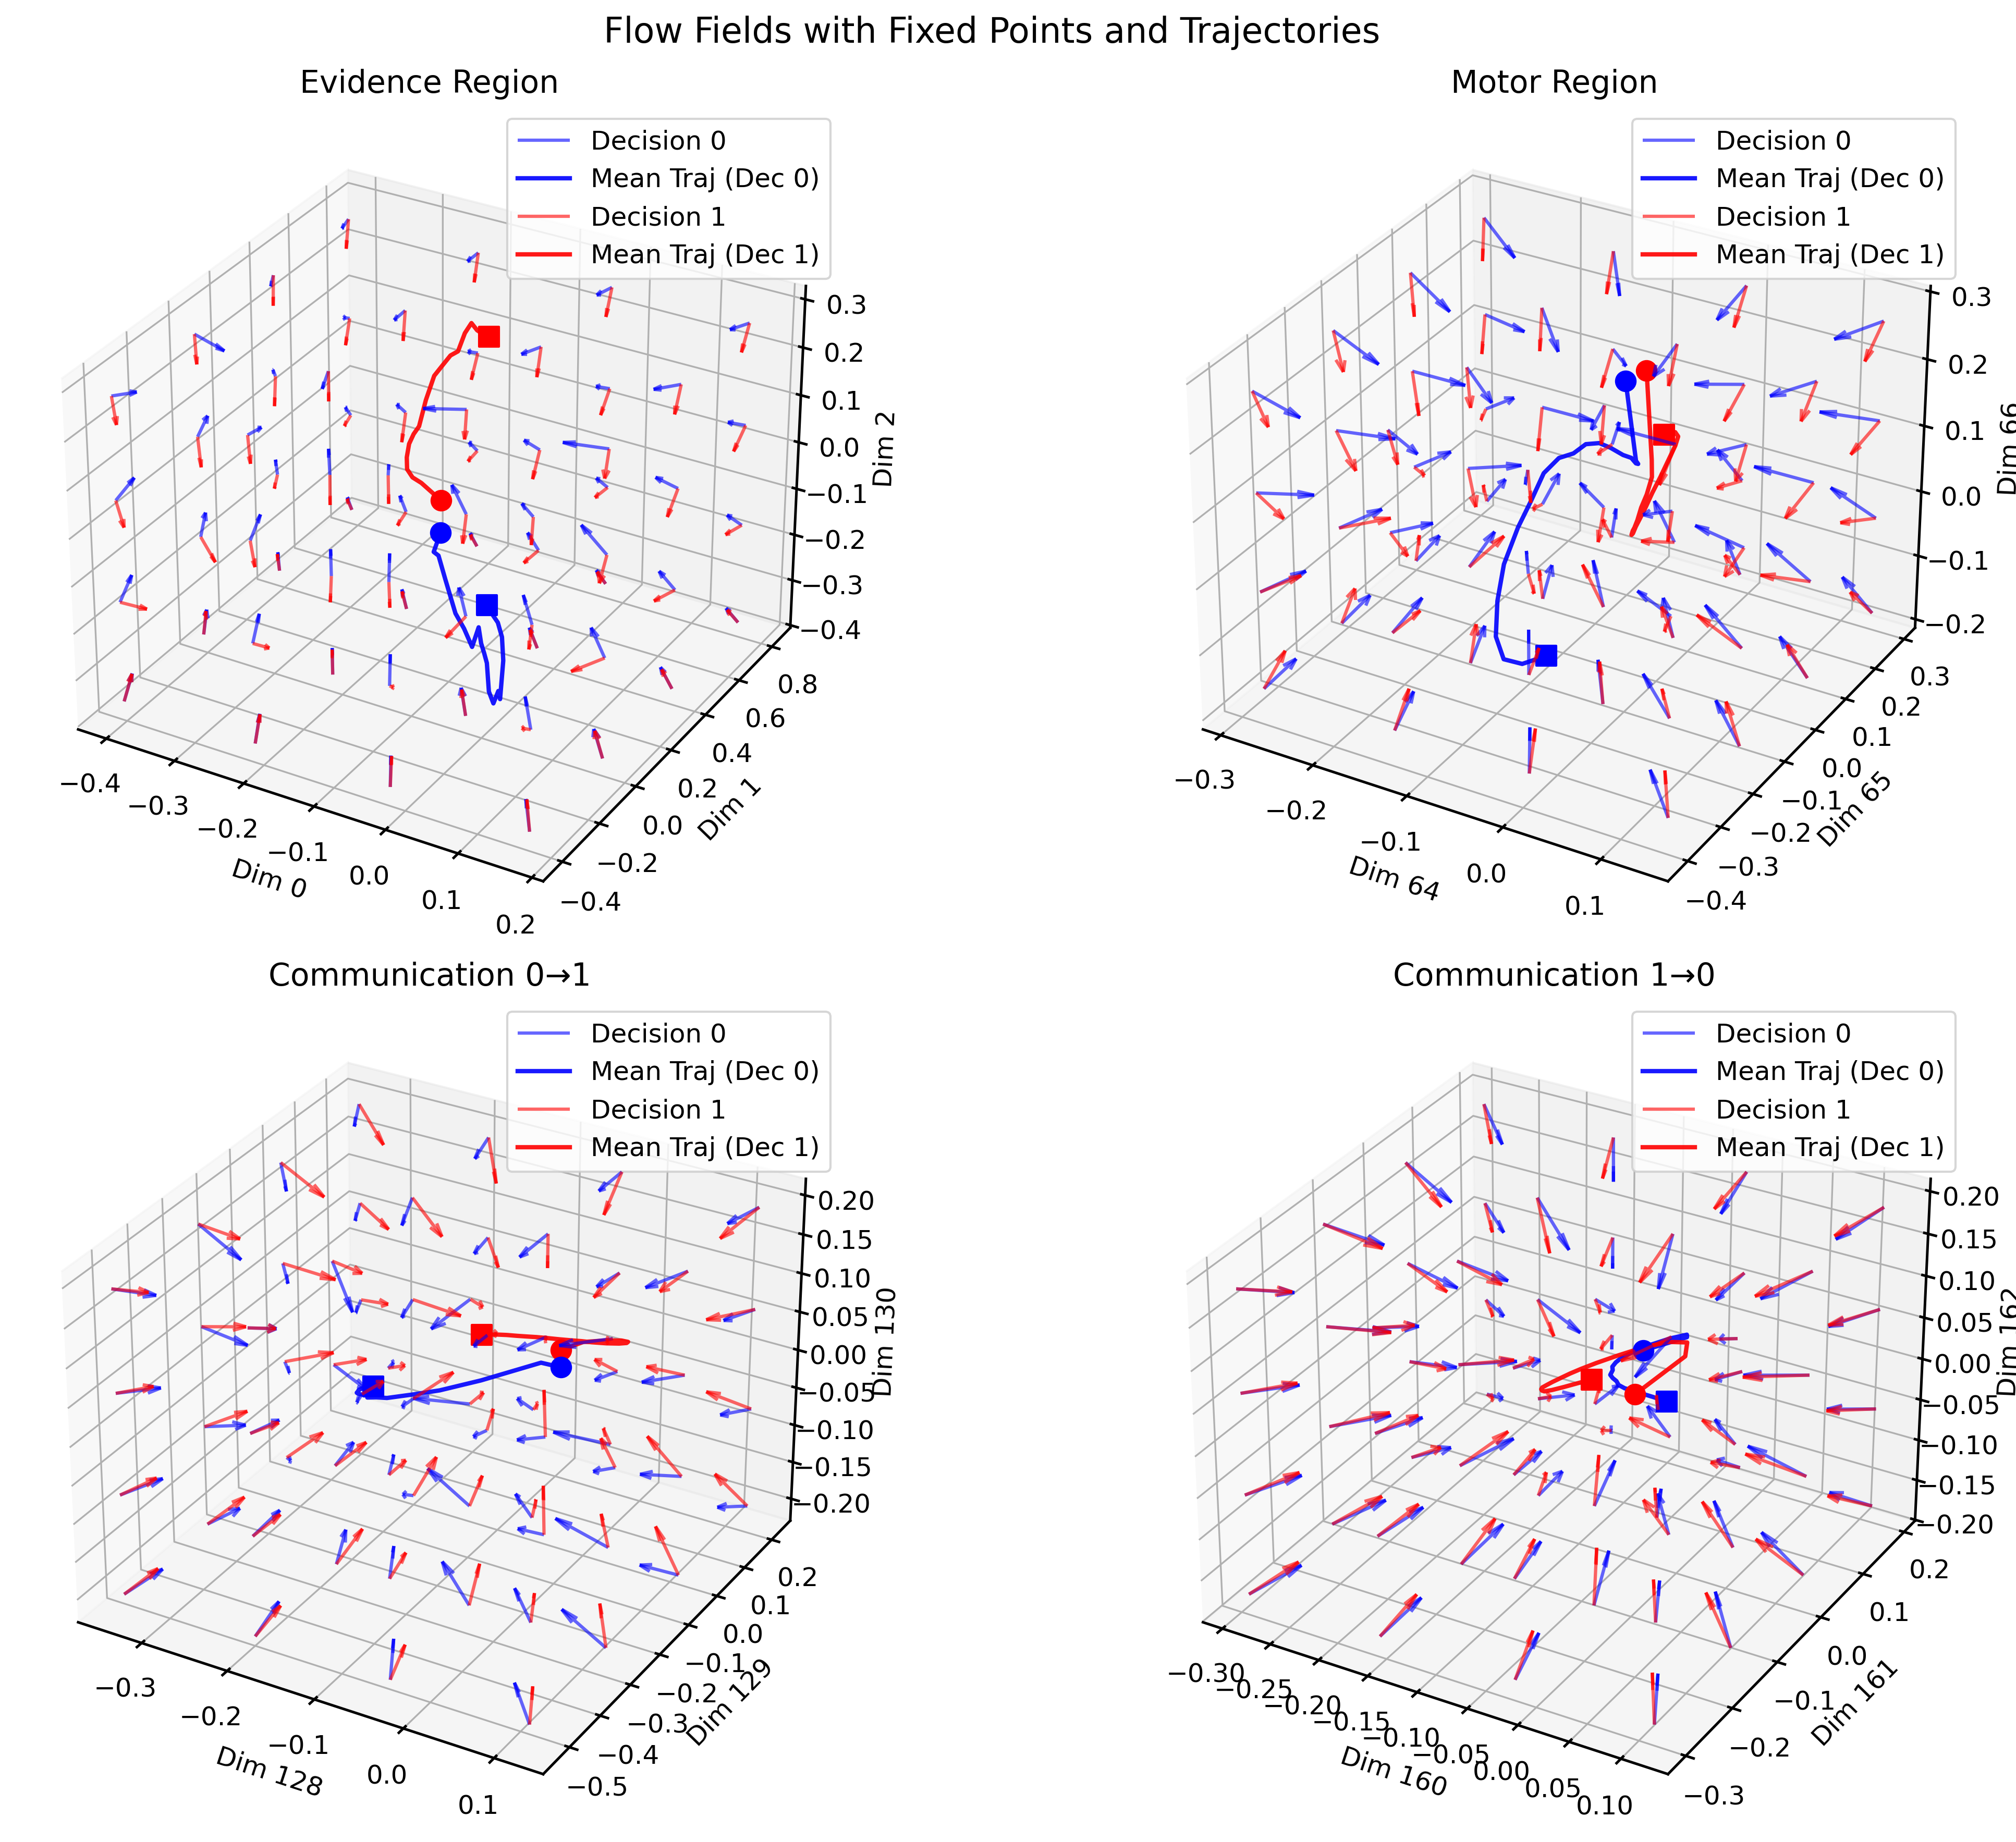


✓ Panel 5 complete - Enhanced 3D flow fields with 15 trials analyzed


In [16]:
def bidirectional_comm_flow_analysis(model, trajectories, reconstruction_data, 
                                   n_trials=10, arrow_downsample=2, show_fixed_points=True, 
                                   show_trajectories=True, n_traj_samples=3, arrow_len=0.2,
                                   traj_linewidth=3, arrow_alpha=0.7, traj_alpha=0.8):
    """Enhanced flow analysis with fixed points and trajectory visualization"""
    model.eval()
    device = next(model.parameters()).device
    dt = 0.01
    
    print(f"=== Enhanced Bidirectional Flow Analysis ===")
    print(f"Model: {model.num_regions} regions, {model.N_total} total dims")
    
    # Collect trial data
    trial_data = []
    for trial_idx in range(min(n_trials, len(reconstruction_data))):
        inputs, decision_type = reconstruction_data[trial_idx]
        if isinstance(inputs, torch.Tensor):
            inputs = inputs.detach().cpu().numpy()
        
        # Run trajectory
        states = []
        with torch.no_grad():
            h = torch.empty(1, model.N_total, device=device)
            torch.nn.init.xavier_uniform_(h)
            for t in range(min(20, len(inputs))):
                x_t = torch.FloatTensor(inputs[t:t+1]).to(device)
                h_dot, _ = model(h, x_t, timestep=t)
                h = h + dt * h_dot
                states.append(h[0].detach().cpu().numpy())
        
        trial_data.append({'states': np.array(states), 'decision': decision_type})
    
    # Define component dimensions
    comm_start = model.N_regions
    components = [
        ('Evidence Region', [0, 1, 2]),
        ('Motor Region', [model.N_regions//2, model.N_regions//2+1, model.N_regions//2+2]),
        ('Communication 0→1', [comm_start, comm_start+1, comm_start+2]),
        ('Communication 1→0', [comm_start + model.comm_dim, comm_start + model.comm_dim + 1, comm_start + model.comm_dim + 2])
    ]
    
    # Create plots
    fig, axes = plt.subplots(2, 2, figsize=(16, 12), subplot_kw={'projection': '3d'})
    fig.suptitle('Flow Fields with Fixed Points and Trajectories', fontsize=16)
    
    all_states = np.vstack([trial['states'] for trial in trial_data])
    
    for (comp_name, dims), ax in zip(components, axes.flatten()):
        if any(d >= all_states.shape[1] for d in dims):
            ax.text(0.5, 0.5, 0.5, f'{comp_name}\nNot Available', ha='center', va='center')
            continue
        
        # Get data bounds with margin
        bounds = [(np.percentile(all_states[:, d], [10, 90]) + np.array([-0.2, 0.2])) for d in dims]
        
        # Create flow field grid
        grid_size = 8
        grids = [np.linspace(*bound, grid_size) for bound in bounds]
        X, Y, Z = np.meshgrid(*grids)
        
        # Compute flow for each decision type
        for decision_type in [0, 1]:
            decision_trials = [t for t in trial_data if t['decision'] == decision_type]
            if not decision_trials:
                continue
            
            # Get representative state
            rep_states = np.vstack([t['states'] for t in decision_trials])
            mean_state = rep_states.mean(axis=0)
            
            U, V, W = np.zeros_like(X), np.zeros_like(Y), np.zeros_like(Z)
            fixed_points = []
            
            with torch.no_grad():
                for i, j, k in np.ndindex(grid_size, grid_size, grid_size):
                    h_test = torch.FloatTensor(mean_state).unsqueeze(0).to(device)
                    for idx, dim in enumerate(dims):
                        h_test[0, dim] = [X, Y, Z][idx][i, j, k]
                    
                    x_input = torch.zeros(1, model.num_regions, 64, device=device)
                    h_dot, _ = model(h_test, x_input, timestep=10)
                    
                    U[i, j, k], V[i, j, k], W[i, j, k] = [h_dot[0, d].cpu().numpy() for d in dims]
                    
                    # Check for fixed points
                    if show_fixed_points and np.linalg.norm([U[i,j,k], V[i,j,k], W[i,j,k]]) < 0.02:
                        fixed_points.append([X[i,j,k], Y[i,j,k], Z[i,j,k]])
            
            color = 'blue' if decision_type == 0 else 'red'
            step = arrow_downsample
            
            # Plot flow field
            ax.quiver(X[::step, ::step, ::step], Y[::step, ::step, ::step], Z[::step, ::step, ::step],
                     U[::step, ::step, ::step], V[::step, ::step, ::step], W[::step, ::step, ::step],
                     length=arrow_len, normalize=True, alpha=arrow_alpha, color=color, 
                     label=f'Decision {decision_type}')
            
            # Plot fixed points
            if show_fixed_points and fixed_points:
                fp_array = np.array(fixed_points)
                ax.scatter(fp_array[:, 0], fp_array[:, 1], fp_array[:, 2], 
                          c='black', s=50, marker='x', alpha=0.8, 
                          label=f'Fixed Points (Dec {decision_type})')
            
            # Plot mean trajectory with start/end markers
            if show_trajectories and decision_trials:
                min_len = min(len(trial['states']) for trial in decision_trials)
                traj_stack = np.stack([trial['states'][:min_len] for trial in decision_trials])
                mean_traj = traj_stack.mean(axis=0)
                
                traj_coords = [mean_traj[:, d] for d in dims]
                
                # Plot trajectory line
                ax.plot(*traj_coords, color=color, alpha=traj_alpha, linewidth=traj_linewidth, 
                       label=f'Mean Traj (Dec {decision_type})')
                
                # Add start (dot) and end (square) markers
                ax.scatter(*[coord[0] for coord in traj_coords], c=color, s=80, marker='o', alpha=1.0)  # start
                ax.scatter(*[coord[-1] for coord in traj_coords], c=color, s=80, marker='s', alpha=1.0)  # end
        
        ax.set_xlabel(f'Dim {dims[0]}')
        ax.set_ylabel(f'Dim {dims[1]}')
        ax.set_zlabel(f'Dim {dims[2]}')
        ax.set_title(comp_name)
        ax.legend()
    
    plt.tight_layout()
    return fig, trial_data


# Run the analysis
print("="*50)
print("PANEL 5: Enhanced 3D Flow Fields") 
print("="*50)

if mr_gnode_model is not None and 'test_data' in locals():
    print("Preparing reconstruction data...")
    
    reconstruction_data = []
    n_trials = 15
    
    for trial_idx in range(n_trials):
        evidence = test_data['evidence_states'][trial_idx]
        motor = test_data['motor_states'][trial_idx]
        
        combined_inputs = []
        for t in range(len(evidence)):
            combined = np.concatenate([evidence[t], motor[t]])
            combined_inputs.append(combined.reshape(2, 64))
        
        inputs = np.array(combined_inputs)
        decision_type = test_data['trial_info'][trial_idx]['target']
        reconstruction_data.append((inputs, decision_type))
    
    print(f"Prepared {len(reconstruction_data)} trials for flow analysis")
    
    panel5_fig, flow_trial_data = bidirectional_comm_flow_analysis(
        mr_gnode_model, None, reconstruction_data,
        n_trials=n_trials, arrow_downsample=2, show_fixed_points=True, 
        show_trajectories=True, n_traj_samples=5, arrow_len=0.06,
        traj_linewidth=2, arrow_alpha=0.6, traj_alpha=0.9
    )
    
    plt.show()
    print(f"\n✓ Panel 5 complete - Enhanced 3D flow fields with {len(flow_trial_data)} trials analyzed")
    
else:
    print("⚠ MR-GNODE model or test_data not available")

DENOISING PERFORMANCE ANALYSIS
Loading denoising results (noise=0.1, mask=0.1)...
Looking for denoising results...
Found 9 denoising result files
  kalman_filter: ['mask', 'noise', 'clean']
  mr_gnode: ['mask', 'noise', 'clean']
  rrr: ['mask', 'noise', 'clean']
✓ Found results for 3 models

Performance Summary (R²):
------------------------------------------------------------
Model           | Clean      | Noise      | Mask      
------------------------------------------------------------
KALMAN-FILTER   | 0.964      | 0.972      | 0.207
MR-GNODE        | 0.984      | 0.979      | 0.942
RRR             | 0.922      | 0.671      | 0.508
------------------------------------------------------------


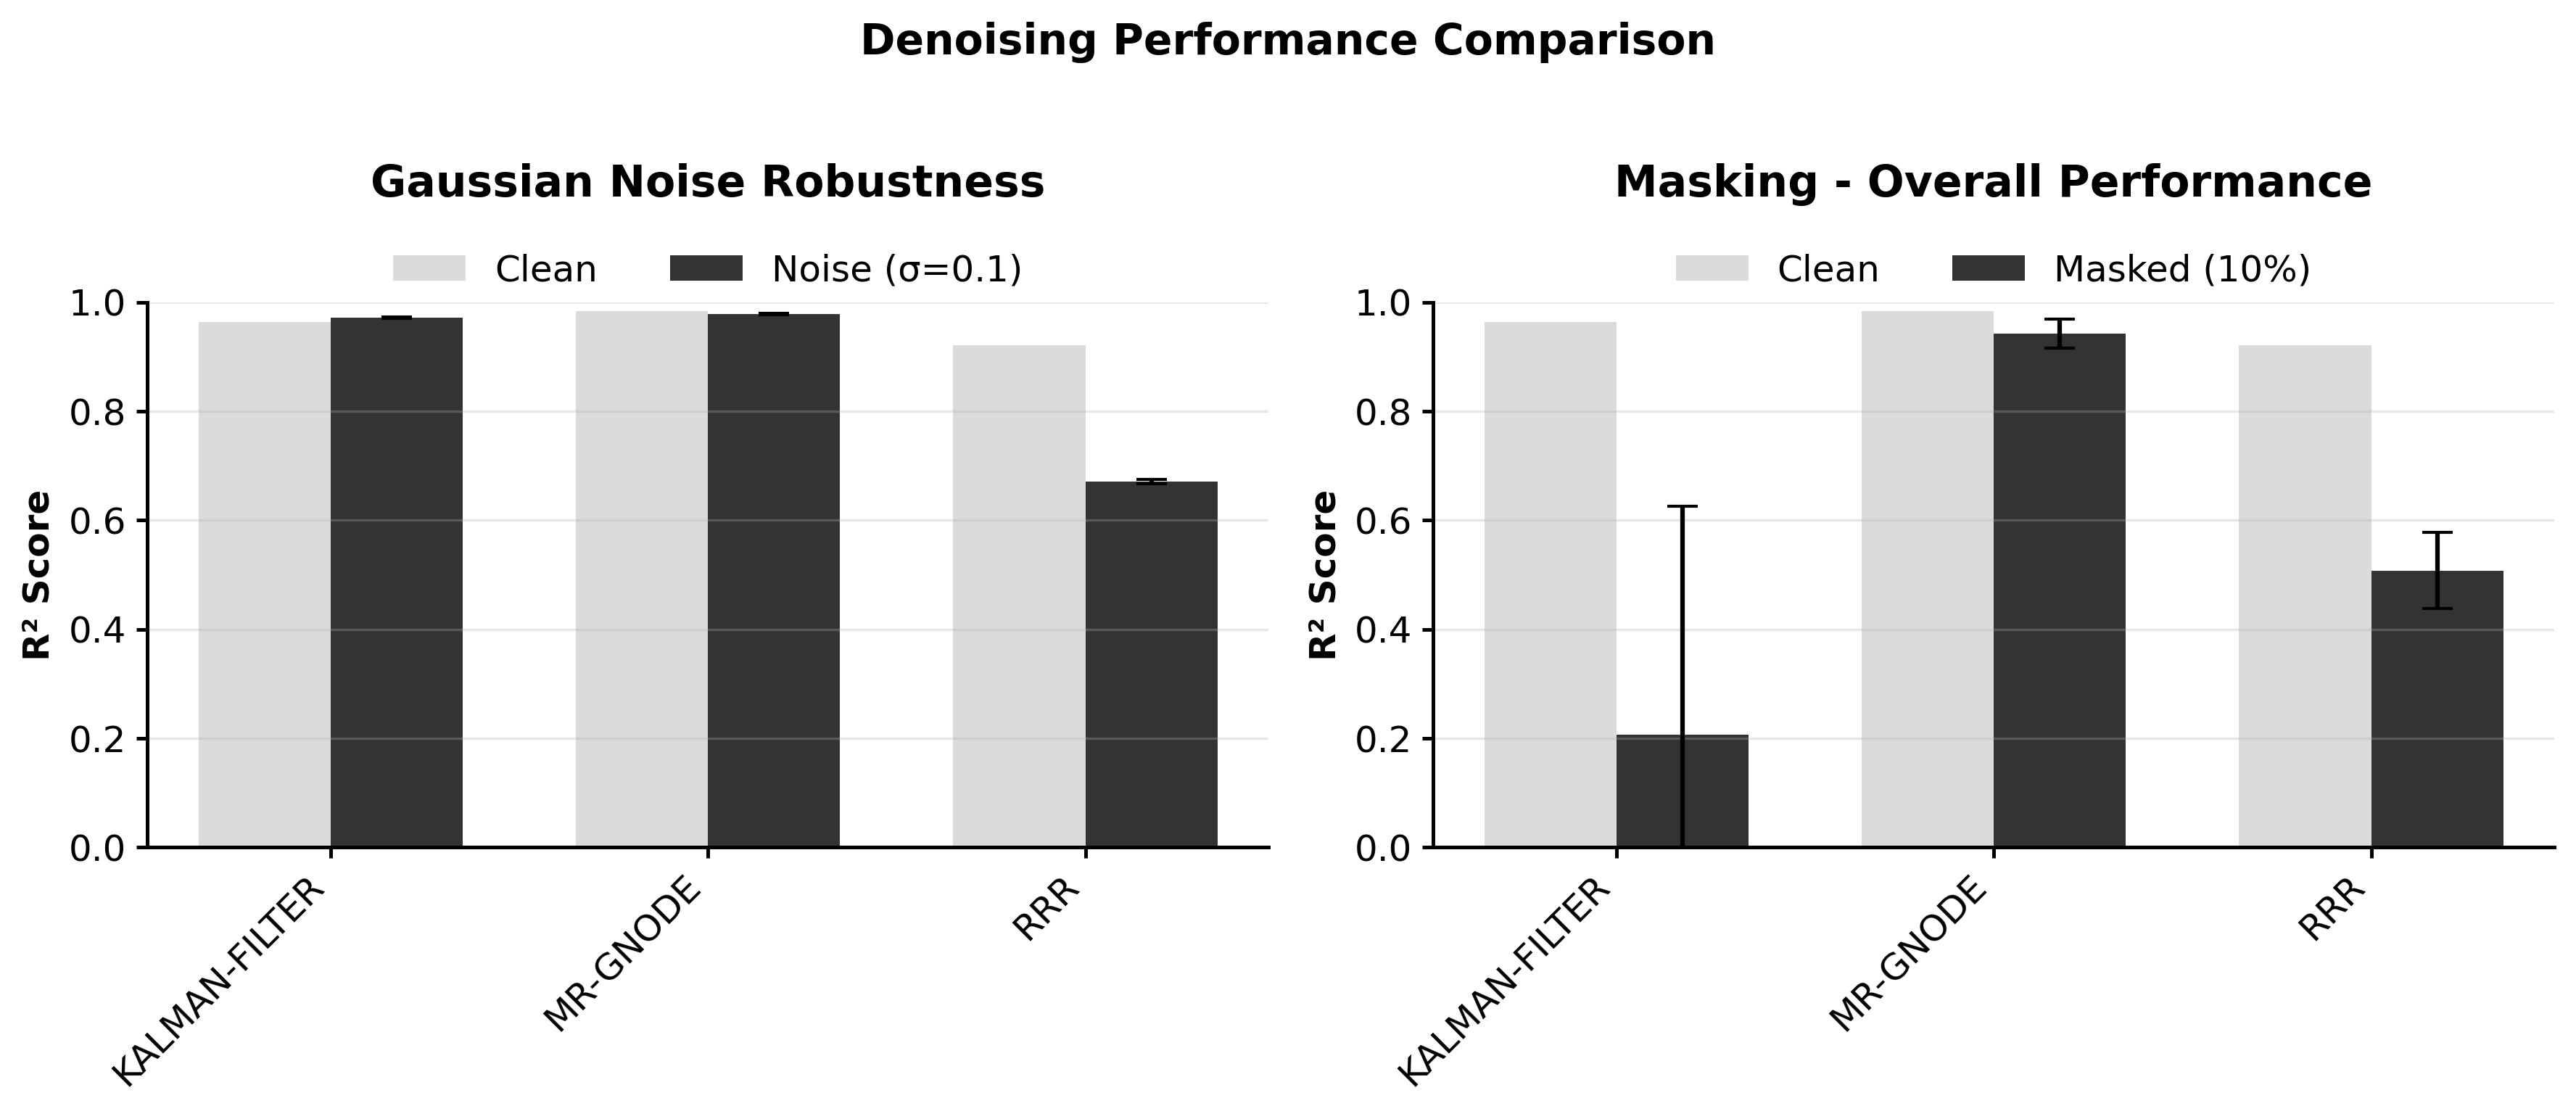

In [26]:
"""
Cell: Denoising Performance - Noise & Masking Results
"""
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Load denoising results
def load_denoising_results(cache_dir='cache', noise_level=0.1, mask_ratio=0.1):
    """Load denoising CV results for specific corruption levels"""
    results = {}
    
    # Debug: show what files exist
    print("Looking for denoising results...")
    denoising_paths = list(Path(cache_dir).glob('*_cv_denoising_*/cv_results.json'))
    print(f"Found {len(denoising_paths)} denoising result files")
    
    # Load all denoising results
    for path in denoising_paths:
        with open(path) as f:
            data = json.load(f)
            model = data['model_type']
            corruption = data['corruption_type']
            level = data['corruption_level']
            
            if model not in results:
                results[model] = {}
            
            # Store by corruption type
            if corruption == 'none' and level == 0.0:
                results[model]['clean'] = data
            elif corruption == 'noise' and abs(level - noise_level) < 0.001:
                results[model]['noise'] = data
            elif corruption == 'mask' and abs(level - mask_ratio) < 0.001:
                results[model]['mask'] = data
    
    # Debug output
    for model in results:
        print(f"  {model}: {list(results[model].keys())}")
    
    return results

# Create comparison plot
def plot_denoising_comparison(results, noise_level=0.1, mask_ratio=0.1, metric='r2'):
    """Create side-by-side bar plots for noise and masking results
    
    Args:
        results: Dictionary of denoising results
        noise_level: Noise level to display
        mask_ratio: Mask ratio to display
        metric: 'r2' or 'mse' for performance metric
    """
    
    # Prepare data
    models = sorted(results.keys())
    
    # Extract metrics based on choice
    if metric == 'r2':
        metric_key = 'mean_test_r2'
        std_key = 'std_test_r2'
        ylabel = 'R² Score'
        ylim = [0, 1]
    else:  # mse
        metric_key = 'mean_test_mse'
        std_key = 'std_test_mse'
        ylabel = 'Mean Squared Error'
        ylim = None  # Auto scale for MSE
    
    clean_vals = []
    noise_vals = []
    noise_std = []
    mask_vals = []
    mask_std = []
    
    for model in models:
        # Clean baseline
        if 'clean' in results[model]:
            clean_vals.append(results[model]['clean'][metric_key])
        else:
            clean_vals.append(0)
        
        # Noise results
        if 'noise' in results[model]:
            noise_vals.append(results[model]['noise'][metric_key])
            noise_std.append(results[model]['noise'][std_key])
        else:
            noise_vals.append(0)
            noise_std.append(0)
        
        # Mask results
        if 'mask' in results[model]:
            mask_vals.append(results[model]['mask'][metric_key])
            mask_std.append(results[model]['mask'][std_key])
        else:
            mask_vals.append(0)
            mask_std.append(0)
    
    # Create figure
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Model names for x-axis
    model_names = [m.replace('_', '-').upper() for m in models]
    x = np.arange(len(model_names))
    width = 0.35
    
    # 1. Noise Performance
    ax1 = axes[0]
    bars1 = ax1.bar(x - width/2, clean_vals, width, label='Clean', color='lightgray', alpha=0.8)
    bars2 = ax1.bar(x + width/2, noise_vals, width, yerr=noise_std, 
                    label=f'Noise (σ={noise_level})', color='black', alpha=0.8, capsize=5)
    
    ax1.set_ylabel(ylabel, fontweight='bold')
    ax1.set_title(f'Gaussian Noise Robustness', fontweight='bold', pad=35)
    ax1.set_xticks(x)
    ax1.set_xticklabels(model_names, rotation=45, ha='right')
    ax1.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=2, frameon=False)
    ax1.grid(True, alpha=0.3, axis='y')
    if ylim:
        ax1.set_ylim(ylim)
    
    # 2. Masking - Overall Performance
    ax2 = axes[1]
    bars3 = ax2.bar(x - width/2, clean_vals, width, label='Clean', color='lightgray', alpha=0.8)
    bars4 = ax2.bar(x + width/2, mask_vals, width, yerr=mask_std,
                    label=f'Masked ({int(mask_ratio*100)}%)', color='black', alpha=0.8, capsize=5)
    
    ax2.set_ylabel(ylabel, fontweight='bold')
    ax2.set_title(f'Masking - Overall Performance', fontweight='bold', pad=35)
    ax2.set_xticks(x)
    ax2.set_xticklabels(model_names, rotation=45, ha='right')
    ax2.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=2, frameon=False)
    ax2.grid(True, alpha=0.3, axis='y')
    if ylim:
        ax2.set_ylim(ylim)
    
    plt.suptitle('Denoising Performance Comparison', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    return fig

# ================================
# Main Execution
# ================================
print("="*50)
print("DENOISING PERFORMANCE ANALYSIS")
print("="*50)

# Load results
noise_level = 0.1  # From config
mask_ratio = 0.1   # From config
metric = 'r2'  # Change to 'mse' to show Mean Squared Error instead

print(f"Loading denoising results (noise={noise_level}, mask={mask_ratio})...")
denoising_results = load_denoising_results(noise_level=noise_level, mask_ratio=mask_ratio)

if denoising_results:
    print(f"✓ Found results for {len(denoising_results)} models\n")
    
    # Print summary
    metric_label = 'R²' if metric == 'r2' else 'MSE'
    metric_key = 'mean_test_r2' if metric == 'r2' else 'mean_test_mse'
    
    print(f"Performance Summary ({metric_label}):")
    print("-" * 60)
    print(f"{'Model':<15} | {'Clean':<10} | {'Noise':<10} | {'Mask':<10}")
    print("-" * 60)
    
    for model in sorted(denoising_results.keys()):
        clean = denoising_results[model].get('clean', {}).get(metric_key, 0)
        noise = denoising_results[model].get('noise', {}).get(metric_key, 0)
        mask_overall = denoising_results[model].get('mask', {}).get(metric_key, 0)
        
        model_name = model.replace('_', '-').upper()
        if metric == 'r2':
            print(f"{model_name:<15} | {clean:.3f}      | {noise:.3f}      | {mask_overall:.3f}")
        else:  # MSE - use scientific notation if needed
            print(f"{model_name:<15} | {clean:.4f}    | {noise:.4f}    | {mask_overall:.4f}")
    
    print("-" * 60)
    
    # Create plot
    robust_cv_fig = plot_denoising_comparison(denoising_results, noise_level, mask_ratio, metric=metric)
    plt.show()
    
else:
    print("❌ No denoising results found!")
    print("   Run: python cross_validate_denoising.py configs/model.json")
    print("\n   Check if files exist with pattern:")
    print("   cache/*_cv_denoising_*/cv_results.json")

## Save Figures

In [27]:

panel1_fig.savefig('plots/fig2_panel1.svg', bbox_inches='tight')
cv_fig.savefig('plots/fig2_panel2.svg', bbox_inches='tight')
robust_cv_fig.savefig('plots/fig2_panel3.svg', bbox_inches='tight')
panel3_fig.savefig('plots/fig2_panel4.svg', bbox_inches='tight')
panel5_fig.savefig('plots/fig2_panel5.svg', bbox_inches='tight')


NameError: name 'panel1_fig' is not defined